In [1]:
%pip install python-dotenv


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install qiskit-ibm-runtime


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


TABLO 1: KLASİK ALGORİTMA ÇALIŞMA SÜRELERİ
-----------------------------------------------------------------
Hedef N Değeri       | Çarpanlar (p, q)     | Süre (ms)      
-----------------------------------------------------------------
15                   | 3, 5                 | 0.0023
21                   | 3, 7                 | 0.0010
10403                | 101, 103             | 0.0025
9999999900000001     | Bulunamadı           | 2101.4988
-----------------------------------------------------------------

TABLO 2: KUANTUM SİMÜLASYON VE DONANIM ANALİZİ
-----------------------------------------------------------------
Platform       : Yerel Simülatör (Qiskit Aer)
Çalışma Süresi : 43.2116 ms
En Yüksek 3 Durum: [('10100', 45), ('01111', 43), ('10011', 40)]

Platform       : Fiziksel Donanım (ibm_marrakesh)
Çalışma Süresi : 8.05 saniye (Kuyruk Dahil)
En Yüksek 3 Durum: [('01110', 43), ('00111', 40), ('00001', 39)]
-----------------------------------------------------------------



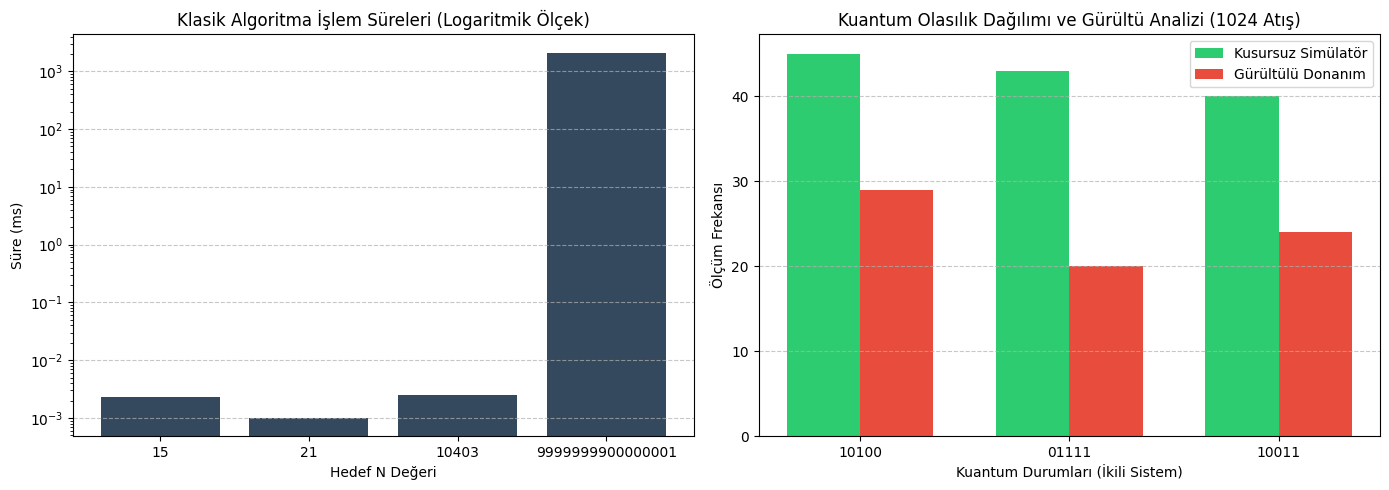

In [3]:
import time
import math
import warnings
import logging
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.circuit.library import QFT

import os
from dotenv import load_dotenv

load_dotenv()

# Uyarı (Warning) ve Log mesajlarını gizleme (Temiz ekran görüntüsü için)
warnings.filterwarnings('ignore')
logging.getLogger("qiskit_ibm_runtime").setLevel(logging.ERROR)

# ==========================================
# BÖLÜM 1: KLASİK ALGORİTMA PERFORMANS ANALİZİ
# ==========================================
def classical_factorization(n):
    for i in range(2, int(math.sqrt(n)) + 1):
        if n % i == 0:
            return i, n // i
    return None, None

print("TABLO 1: KLASİK ALGORİTMA ÇALIŞMA SÜRELERİ")
print("-" * 65)
print(f"{'Hedef N Değeri':<20} | {'Çarpanlar (p, q)':<20} | {'Süre (ms)':<15}")
print("-" * 65)

test_numbers = [15, 21, 10403, 9999999900000001]
classical_times = []

for n_val in test_numbers:
    c_start_time = time.perf_counter()
    p, q = classical_factorization(n_val)
    c_end_time = time.perf_counter()
    
    elapsed_ms = (c_end_time - c_start_time) * 1000
    classical_times.append(elapsed_ms)
    
    factors_str = f"{p}, {q}" if p else "Bulunamadı"
    print(f"{n_val:<20} | {factors_str:<20} | {elapsed_ms:.4f}")
print("-" * 65 + "\n")

# ==========================================
# BÖLÜM 2: KUANTUM DEVRE TASARIMI (10 KÜBİT)
# ==========================================
qc_heavy = QuantumCircuit(10, 5)
for q_idx in range(5):
    qc_heavy.h(q_idx)

for i in range(5):
    qc_heavy.cx(i, i+5)
    if i < 4:
        qc_heavy.cx(i, i+6)

qc_heavy.append(QFT(5, inverse=True).to_instruction(), range(5))
qc_heavy.measure(range(5), range(5))

# ==========================================
# BÖLÜM 3: YEREL KUANTUM SİMÜLASYONU
# ==========================================
print("TABLO 2: KUANTUM SİMÜLASYON VE DONANIM ANALİZİ")
print("-" * 65)

sim_start_time = time.perf_counter()
simulator = AerSimulator()
compiled_sim = transpile(qc_heavy, simulator)
sim_job = simulator.run(compiled_sim, shots=1024)
sim_counts = sim_job.result().get_counts()
sim_time_ms = (time.perf_counter() - sim_start_time) * 1000

top_3_sim = sorted(sim_counts.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Platform       : Yerel Simülatör (Qiskit Aer)")
print(f"Çalışma Süresi : {sim_time_ms:.4f} ms")
print(f"En Yüksek 3 Durum: {top_3_sim}\n")


# ==========================================
# BÖLÜM 4: IBM FİZİKSEL KUANTUM DONANIMI
# ==========================================
IBM_TOKEN = os.getenv("IBM_QUANTUM_TOKEN")

if not IBM_TOKEN:
    raise ValueError("HATA: API Anahtarı bulunamadı! Lütfen .env dosyanızı kontrol edin.")

service = QiskitRuntimeService(channel="ibm_quantum_platform", token=IBM_TOKEN)
backend = service.least_busy(operational=True, simulator=False)

print(f"Platform       : Fiziksel Donanım ({backend.name})")

real_start_time = time.perf_counter()
compiled_real = transpile(qc_heavy, backend, optimization_level=3)
sampler = Sampler(backend)
real_job = sampler.run([compiled_real], shots=1024)
real_counts = real_job.result()[0].data.c.get_counts() 
real_time_sec = time.perf_counter() - real_start_time

top_3_real = sorted(real_counts.items(), key=lambda x: x[1], reverse=True)[:3]
print(f"Çalışma Süresi : {real_time_sec:.2f} saniye (Kuyruk Dahil)")
print(f"En Yüksek 3 Durum: {top_3_real}")
print("-" * 65 + "\n")

# ==========================================
# BÖLÜM 5: VERİ GÖRSELLEŞTİRME VE KARŞILAŞTIRMA
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafik 1: Klasik Algoritma Süre Analizi (Logaritmik)
x_labels = [str(n) for n in test_numbers]
ax1.bar(x_labels, classical_times, color='#34495e')
ax1.set_yscale('log')
ax1.set_title('Klasik Algoritma İşlem Süreleri (Logaritmik Ölçek)')
ax1.set_ylabel('Süre (ms)')
ax1.set_xlabel('Hedef N Değeri')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Grafik 2: Kuantum Gürültü (Decoherence) Karşılaştırması
# En yüksek 3 simülasyon sonucunun gerçek donanımdaki karşılıkları
keys = [item[0] for item in top_3_sim]
sim_values = [item[1] for item in top_3_sim]
real_values = [real_counts.get(k, 0) for k in keys]

x = np.arange(len(keys))
width = 0.35

ax2.bar(x - width/2, sim_values, width, label='Kusursuz Simülatör', color='#2ecc71')
ax2.bar(x + width/2, real_values, width, label='Gürültülü Donanım', color='#e74c3c')

ax2.set_title('Kuantum Olasılık Dağılımı ve Gürültü Analizi (1024 Atış)')
ax2.set_ylabel('Ölçüm Frekansı')
ax2.set_xlabel('Kuantum Durumları (İkili Sistem)')
ax2.set_xticks(x)
ax2.set_xticklabels(keys)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('deneysel_sonuclar_analizi.png', dpi=300, bbox_inches='tight')
plt.show()